In [1]:
import sys
sys.path.append('..')

import pandas as pd
import plotly.express as px
from entsoe import EntsoePandasClient
from dotenv import load_dotenv
import os

load_dotenv(dotenv_path=r"C:\Users\IvaRichterová\Desktop\entsoe-dashboard\.env")
TOKEN = os.getenv("ENTSOE_TOKEN")

client = EntsoePandasClient(api_key=TOKEN)

konec   = pd.Timestamp.now(tz="UTC").floor("h")
zacatek = konec - pd.Timedelta(days=30)

print("✓ Vše připraveno")

✓ Vše připraveno


In [2]:
import os
import pandas as pd
from datetime import datetime, timedelta

cache_slozka = r"C:\Users\IvaRichterová\Desktop\entsoe-dashboard\data\cache"

# Actual load
soubor_actual_parquet = os.path.join(cache_slozka, "load_actual.parquet")
soubor_actual_csv = os.path.join(cache_slozka, "load_actual.csv")

if os.path.exists(soubor_actual_parquet):
    stari = datetime.now() - datetime.fromtimestamp(os.path.getmtime(soubor_actual_parquet))
    if stari < timedelta(hours=24):
        print(f"  ✓ Actual load: načteno z cache")
        load_actual = pd.read_parquet(soubor_actual_parquet)
        load_actual.index = load_actual.index.tz_convert("Europe/Prague")
    else:
        load_actual = None
else:
    load_actual = None

if load_actual is None:
    print("  Stahuji actual load z API...")
    load_actual = client.query_load(
        country_code="10YCZ-CEPS-----N",
        start=zacatek,
        end=konec,
    )
    load_actual = load_actual.tz_convert("Europe/Prague")
    load_actual.to_parquet(soubor_actual_parquet)
    load_actual.to_csv(soubor_actual_csv)
    print(f"  ✓ Actual load: staženo ({len(load_actual)} hodnot)")

# Forecast load
soubor_forecast_parquet = os.path.join(cache_slozka, "load_forecast.parquet")
soubor_forecast_csv = os.path.join(cache_slozka, "load_forecast.csv")

if os.path.exists(soubor_forecast_parquet):
    stari = datetime.now() - datetime.fromtimestamp(os.path.getmtime(soubor_forecast_parquet))
    if stari < timedelta(hours=24):
        print(f"  ✓ Forecast load: načteno z cache")
        load_forecast = pd.read_parquet(soubor_forecast_parquet)
        load_forecast.index = load_forecast.index.tz_convert("Europe/Prague")
    else:
        load_forecast = None
else:
    load_forecast = None

if load_forecast is None:
    print("  Stahuji forecast load z API...")
    load_forecast = client.query_load_forecast(
        country_code="10YCZ-CEPS-----N",
        start=zacatek,
        end=konec,
    )
    load_forecast = load_forecast.tz_convert("Europe/Prague")
    load_forecast.to_parquet(soubor_forecast_parquet)
    load_forecast.to_csv(soubor_forecast_csv)
    print(f"  ✓ Forecast load: staženo ({len(load_forecast)} hodnot)")

  Stahuji actual load z API...
  ✓ Actual load: staženo (2876 hodnot)
  Stahuji forecast load z API...
  ✓ Forecast load: staženo (2880 hodnot)


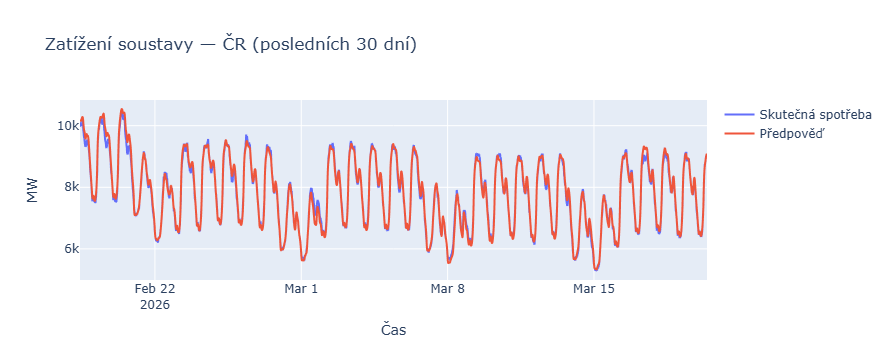

In [3]:
# Vybereme jen sloupce s hodnotami
df_load = pd.DataFrame({
    "Skutečná spotřeba": load_actual["Actual Load"],
    "Předpověď": load_forecast["Forecasted Load"],
})

# Graf
fig = px.line(
    df_load,
    title="Zatížení soustavy — ČR (posledních 30 dní)",
    labels={"value": "MW", "index": "Čas", "variable": ""},
)

fig.show()

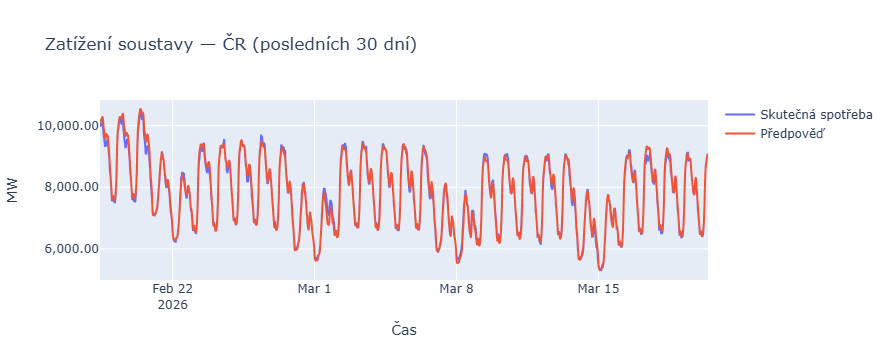

In [4]:
fig = px.line(
    df_load,
    title="Zatížení soustavy — ČR (posledních 30 dní)",
    labels={"value": "MW", "index": "Čas", "variable": ""},
)
fig.update_yaxes(tickformat=",.2f")
fig.show()

In [5]:
print("Typ load_actual:", type(load_actual))
print("Typ load_forecast:", type(load_forecast))
print("\nload_actual prvních 5:")
print(load_actual.head())
print("\nload_forecast prvních 5:")
print(load_forecast.head())

Typ load_actual: <class 'pandas.core.frame.DataFrame'>
Typ load_forecast: <class 'pandas.core.frame.DataFrame'>

load_actual prvních 5:
                           Actual Load
2026-02-18 10:00:00+01:00     10114.95
2026-02-18 10:15:00+01:00     10044.34
2026-02-18 10:30:00+01:00      9970.35
2026-02-18 10:45:00+01:00      9977.45
2026-02-18 11:00:00+01:00     10013.97

load_forecast prvních 5:
                           Forecasted Load
2026-02-18 10:00:00+01:00          10175.0
2026-02-18 10:15:00+01:00          10171.0
2026-02-18 10:30:00+01:00          10168.0
2026-02-18 10:45:00+01:00          10164.0
2026-02-18 11:00:00+01:00          10161.0


In [6]:
print("=== Kontrola dat ===")
print(f"\nActual load:")
print(f"  Období od: {load_actual.index.min()}")
print(f"  Období do: {load_actual.index.max()}")
print(f"  Počet hodnot: {len(load_actual)}")
print(f"  Minimum: {load_actual['Actual Load'].min():.0f} MW")
print(f"  Maximum: {load_actual['Actual Load'].max():.0f} MW")
print(f"  Průměr:  {load_actual['Actual Load'].mean():.0f} MW")

print(f"\nForecast load:")
print(f"  Období od: {load_forecast.index.min()}")
print(f"  Období do: {load_forecast.index.max()}")
print(f"  Počet hodnot: {len(load_forecast)}")
print(f"  Minimum: {load_forecast['Forecasted Load'].min():.0f} MW")
print(f"  Maximum: {load_forecast['Forecasted Load'].max():.0f} MW")
print(f"  Průměr:  {load_forecast['Forecasted Load'].mean():.0f} MW")

print(f"\nSanity check:")
print(f"  Granularita: {load_actual.index[1] - load_actual.index[0]}")
print(f"  Chybějící hodnoty actual: {load_actual['Actual Load'].isna().sum()}")
print(f"  Chybějící hodnoty forecast: {load_forecast['Forecasted Load'].isna().sum()}")

=== Kontrola dat ===

Actual load:
  Období od: 2026-02-18 10:00:00+01:00
  Období do: 2026-03-20 08:45:00+01:00
  Počet hodnot: 2876
  Minimum: 5282 MW
  Maximum: 10463 MW
  Průměr:  7792 MW

Forecast load:
  Období od: 2026-02-18 10:00:00+01:00
  Období do: 2026-03-20 09:45:00+01:00
  Počet hodnot: 2880
  Minimum: 5336 MW
  Maximum: 10542 MW
  Průměr:  7813 MW

Sanity check:
  Granularita: 0 days 00:15:00
  Chybějící hodnoty actual: 0
  Chybějící hodnoty forecast: 0


In [7]:
# Přímý odkaz na zdrojová data na ENTSO-E
print("=== Zdroj dat ===")
print("ENTSO-E Transparency Platform:")
print("https://transparency.entsoe.eu/load-domain/r2/totalLoadR2/show")
print()
print("Parametry dotazu který jsme použili:")
print(f"  Země: ČR (10YCZ-CEPS-----N)")
print(f"  Od:   {zacatek}")
print(f"  Do:   {konec}")
print()

# Ukázka surových dat přesně jak přišla z API
print("=== Surová data — prvních 10 řádků ===")
print(load_actual.head(10).to_string())
print()
print("=== Datové typy sloupců ===")
print(load_actual.dtypes)
print()
print("=== Desetinná místa — používá tečku nebo čárku? ===")
print(load_actual.head(3).to_csv())

=== Zdroj dat ===
ENTSO-E Transparency Platform:
https://transparency.entsoe.eu/load-domain/r2/totalLoadR2/show

Parametry dotazu který jsme použili:
  Země: ČR (10YCZ-CEPS-----N)
  Od:   2026-02-18 09:00:00+00:00
  Do:   2026-03-20 09:00:00+00:00

=== Surová data — prvních 10 řádků ===
                           Actual Load
2026-02-18 10:00:00+01:00     10114.95
2026-02-18 10:15:00+01:00     10044.34
2026-02-18 10:30:00+01:00      9970.35
2026-02-18 10:45:00+01:00      9977.45
2026-02-18 11:00:00+01:00     10013.97
2026-02-18 11:15:00+01:00      9999.08
2026-02-18 11:30:00+01:00     10033.33
2026-02-18 11:45:00+01:00     10067.89
2026-02-18 12:00:00+01:00     10076.56
2026-02-18 12:15:00+01:00     10069.24

=== Datové typy sloupců ===
Actual Load    float64
dtype: object

=== Desetinná místa — používá tečku nebo čárku? ===
,Actual Load
2026-02-18 10:00:00+01:00,10114.95
2026-02-18 10:15:00+01:00,10044.34
2026-02-18 10:30:00+01:00,9970.35



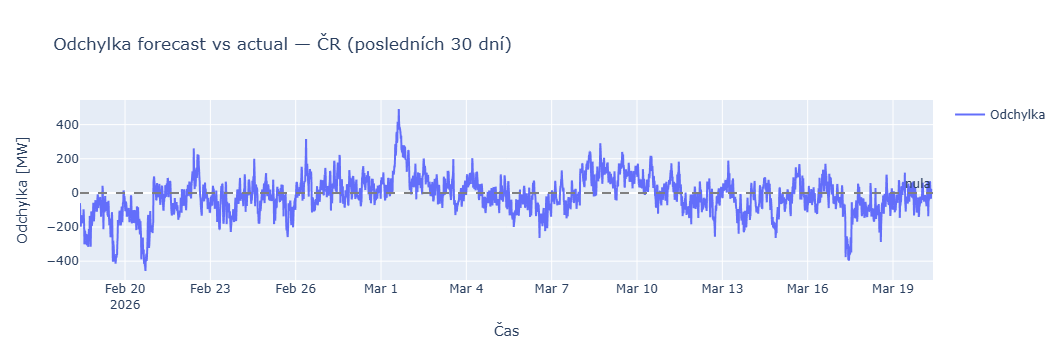

=== Statistiky odchylky ===
  Průměrná odchylka: -18.6 MW
  Největší přecenění: -457.6 MW
  Největší podcenění: 491.6 MW
  Průměrná abs. odchylka: 83.2 MW


In [8]:
# Vypočítáme odchylku
df_load["Odchylka"] = df_load["Skutečná spotřeba"] - df_load["Předpověď"]

# Graf odchylky
fig_odchylka = px.line(
    df_load["Odchylka"],
    title="Odchylka forecast vs actual — ČR (posledních 30 dní)",
    labels={"value": "Odchylka [MW]", "index": "Čas", "variable": ""},
)

# Přidej nulovou linii
fig_odchylka.add_hline(
    y=0,
    line_dash="dash",
    line_color="gray",
    annotation_text="nula",
)

fig_odchylka.show()

# Statistiky odchylky
print("=== Statistiky odchylky ===")
print(f"  Průměrná odchylka: {df_load['Odchylka'].mean():.1f} MW")
print(f"  Největší přecenění: {df_load['Odchylka'].min():.1f} MW")
print(f"  Největší podcenění: {df_load['Odchylka'].max():.1f} MW")
print(f"  Průměrná abs. odchylka: {df_load['Odchylka'].abs().mean():.1f} MW")

In [9]:
# Peak load a base load pro každý den
df_load["den"] = df_load.index.date

denni = df_load.groupby("den")["Skutečná spotřeba"].agg(
    peak_load="max",
    base_load="min",
    prumer="mean"
).round(0)

print("=== Peak load a base load — ČR [MW] ===")
print(denni.to_string())

=== Peak load a base load — ČR [MW] ===
            peak_load  base_load  prumer
den                                     
2026-02-18    10185.0     7746.0  9373.0
2026-02-19    10279.0     7486.0  9048.0
2026-02-20    10463.0     7490.0  9011.0
2026-02-21     9170.0     6595.0  7889.0
2026-02-22     8496.0     6203.0  7370.0
2026-02-23     9449.0     6482.0  8164.0
2026-02-24     9569.0     6567.0  8273.0
2026-02-25     9533.0     6768.0  8251.0
2026-02-26     9714.0     6766.0  8245.0
2026-02-27     9392.0     6312.0  7955.0
2026-02-28     8174.0     5907.0  6880.0
2026-03-01     7985.0     5616.0  6871.0
2026-03-02     9440.0     6449.0  8098.0
2026-03-03     9505.0     6668.0  8164.0
2026-03-04     9424.0     6690.0  8103.0
2026-03-05     9394.0     6580.0  8054.0
2026-03-06     9372.0     6274.0  7845.0
2026-03-07     8062.0     5798.0  6778.0
2026-03-08     7914.0     5632.0  6707.0
2026-03-09     9103.0     6166.0  7781.0
2026-03-10     9106.0     6267.0  7814.0
2026-03-11     90

In [10]:
print(load_actual.head())
print(load_forecast.head())

                           Actual Load
2026-02-18 10:00:00+01:00     10114.95
2026-02-18 10:15:00+01:00     10044.34
2026-02-18 10:30:00+01:00      9970.35
2026-02-18 10:45:00+01:00      9977.45
2026-02-18 11:00:00+01:00     10013.97
                           Forecasted Load
2026-02-18 10:00:00+01:00          10175.0
2026-02-18 10:15:00+01:00          10171.0
2026-02-18 10:30:00+01:00          10168.0
2026-02-18 10:45:00+01:00          10164.0
2026-02-18 11:00:00+01:00          10161.0


In [11]:
print(df_load.head())
print(df_load.dtypes)

                           Skutečná spotřeba  Předpověď  Odchylka         den
2026-02-18 10:00:00+01:00           10114.95    10175.0    -60.05  2026-02-18
2026-02-18 10:15:00+01:00           10044.34    10171.0   -126.66  2026-02-18
2026-02-18 10:30:00+01:00            9970.35    10168.0   -197.65  2026-02-18
2026-02-18 10:45:00+01:00            9977.45    10164.0   -186.55  2026-02-18
2026-02-18 11:00:00+01:00           10013.97    10161.0   -147.03  2026-02-18
Skutečná spotřeba    float64
Předpověď            float64
Odchylka             float64
den                   object
dtype: object


In [12]:
import os

export_slozka = r"C:\Users\IvaRichterová\Desktop\entsoe-dashboard\exports"
os.makedirs(export_slozka, exist_ok=True)

# Graf actual vs forecast
fig.write_image(os.path.join(export_slozka, "02_load_actual_forecast.png"), width=1200, height=600)
fig.write_html(os.path.join(export_slozka, "02_load_actual_forecast.html"))

# Graf odchylky
fig_odchylka.write_image(os.path.join(export_slozka, "02_load_odchylka.png"), width=1200, height=600)
fig_odchylka.write_html(os.path.join(export_slozka, "02_load_odchylka.html"))

print("✓ Exporty notebooku 02 uloženy")

✓ Exporty notebooku 02 uloženy
